In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

In [2]:
df = pd.read_csv("Dataset.csv", sep=",")
print(df.shape)
df.head()


(1048575, 44)


,S.No.,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [3]:
print(df.columns)
print(df['SepsisLabel'].value_counts())

Index(['S.No.', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
       'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST',
       'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID'],
      dtype='object')
0    1027767
1      20808
Name: SepsisLabel, dtype: int64


In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1048575, 44)
Columns: ['S.No.', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


,S.No.,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [5]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Identify feature columns
feature_cols = [col for col in df.columns if col not in ["SepsisLabel", "Patient_ID"]]

# Forward-fill within each patient, then replace remaining NaN with 0
df = (
    df.sort_values(["Patient_ID", "Hour"])
      .groupby("Patient_ID", group_keys=False)[feature_cols]
      .ffill()
      .fillna(0)
)

# Add back patient_id + label
df["Patient_ID"] = pd.read_csv("Dataset.csv")["Patient_ID"]
df["SepsisLabel"] = pd.read_csv("Dataset.csv")["SepsisLabel"]

# ==========================
# STEP 4: Normalize features
# ==========================
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# ==========================
# STEP 5: Create sequences per patient
# ==========================
def create_sequences(patient_df, seq_len=12):
    sequences, labels = [], []
    features = patient_df[feature_cols].values
    targets = patient_df["SepsisLabel"].values
    
    for i in range(len(features) - seq_len):
        sequences.append(features[i:i+seq_len])
        labels.append(targets[i+seq_len])
    return np.array(sequences), np.array(labels)

X_seq, y_seq = [], []
for pid, group in df.groupby("Patient_ID"):
    seqs, lbls = create_sequences(group, seq_len=12)  # 12-hour window
    if len(seqs) > 0:
        X_seq.append(seqs)
        y_seq.append(lbls)

X_seq = np.vstack(X_seq)
y_seq = np.hstack(y_seq)

print("Final X shape:", X_seq.shape)  # (samples, timesteps, features)
print("Final y shape:", y_seq.shape)  # (samples,)

# ==========================
# STEP 6: Train/Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

# ==========================
# STEP 7: Build GRU Model
# ==========================
model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.3),
    GRU(32),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC()])
model.summary()

# ==========================
# STEP 8: Train Model
# ==========================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

# ==========================
# STEP 9: Evaluate
# ==========================
loss, acc, auc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}, AUC: {auc:.4f}")


Final X shape: (725054, 12, 42)
Final y shape: (725054,)


c:\Users\lewin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,177 (117.88 KB)

 Trainable params: 30,177 (117.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 92s 12ms/step - accuracy: 0.9723 - auc: 0.7650 - loss: 0.1033 - val_accuracy: 0.9785 - val_auc: 0.8477 - val_loss: 0.0829
Epoch 2/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 106s 15ms/step - accuracy: 0.9786 - auc: 0.8413 - loss: 0.0830 - val_accuracy: 0.9790 - val_auc: 0.8784 - val_loss: 0.0762
Epoch 3/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 77s 11ms/step - accuracy: 0.9794 - auc: 0.8813 - loss: 0.0743 - val_accuracy: 0.9797 - val_auc: 0.9020 - val_loss: 0.0701
Epoch 4/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 111s 15ms/step - accuracy: 0.9801 - auc: 0.9041 - loss: 0.0682 - val_accuracy: 0.9807 - val_auc: 0.9164 - val_loss: 0.0654
Epoch 5/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 63s 9ms/step - accuracy: 0.9815 - auc: 0.9245 - loss: 0.0614 - val_accuracy: 0.9821 - val_auc: 0.9230 - val_loss: 0.0597
Epoch 6/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step - accuracy: 0.9827 - auc: 0.9359 - loss: 0.0557 - val_accuracy: 0.9829 - val_auc: 0.9400 - val_loss: 0.0546
Epoch 7/10
7251/

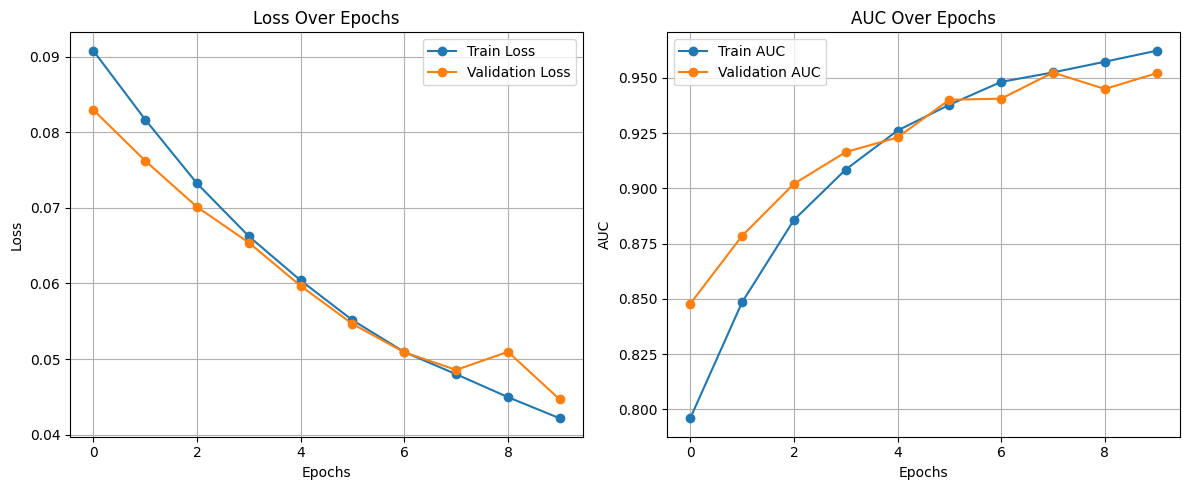

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training & validation AUC
plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC', marker='o')
plt.plot(history.history['val_auc'], label='Validation AUC', marker='o')
plt.title('AUC Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]
train_auc = history.history['auc'][-1]
val_auc = history.history['val_auc'][-1]

print(f"Final Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
print(f"Final Training AUC: {train_auc:.4f}, Validation AUC: {val_auc:.4f}")

Final Training Loss: 0.0422, Validation Loss: 0.0447
Final Training AUC: 0.9622, Validation AUC: 0.9520


In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# y_test = true labels, y_pred = model predictions (threshold 0.5 for binary)
y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Detailed report
print(classification_report(y_test, y_pred))

4532/4532 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Confusion Matrix:
 [[141548    355]
 [  1772   1336]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    141903
           1       0.79      0.43      0.56      3108

    accuracy                           0.99    145011
   macro avg       0.89      0.71      0.77    145011
weighted avg       0.98      0.99      0.98    145011



4532/4532 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


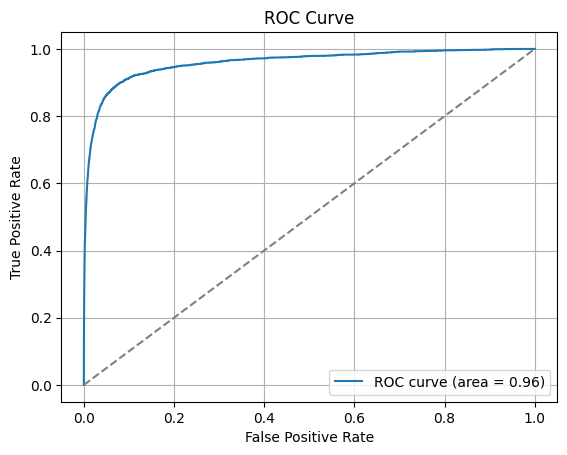

In [9]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# Suppose X_train, y_train are your current training data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train_final)}, Validation samples: {len(X_val)}")

Training samples: 464034, Validation samples: 116009


In [11]:
X = df.drop(columns=['SepsisLabel', 'Patient_ID']).values
y = df['SepsisLabel'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

# Now split into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

X shape: (1048575, 42)
y shape: (1048575,)
Train: (838860, 42) (838860,)
Validation: (209715, 42) (209715,)


In [12]:
timesteps = 12   # sequence length
features = 41

# Convert flat data into sequences
X_seq = []
y_seq = []

for pid, group in df.groupby("Patient_ID"):
    values = group.drop(columns=['SepsisLabel', 'Patient_ID']).values
    labels = group['SepsisLabel'].values
    
    for i in range(len(values) - timesteps + 1):
        X_seq.append(values[i:i+timesteps])
        y_seq.append(labels[i+timesteps-1])  # label = last timestep

X = np.array(X_seq)
y = np.array(y_seq)

print("Final X shape:", X.shape)  # (samples, timesteps, features)
print("Final y shape:", y.shape)


Final X shape: (751507, 12, 42)
Final y shape: (751507,)


In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

Train: (601205, 12, 42) (601205,)
Validation: (150302, 12, 42) (150302,)


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',   # or 'val_auc' if you want
    patience=3,           # stop if no improvement for 3 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,            # large max
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 160s 34ms/step - accuracy: 0.9867 - auc: 0.9575 - loss: 0.0415 - val_accuracy: 0.9884 - val_auc: 0.9687 - val_loss: 0.0367
Epoch 2/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 108s 23ms/step - accuracy: 0.9875 - auc: 0.9650 - loss: 0.0383 - val_accuracy: 0.9886 - val_auc: 0.9690 - val_loss: 0.0350
Epoch 3/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 82s 18ms/step - accuracy: 0.9880 - auc: 0.9692 - loss: 0.0359 - val_accuracy: 0.9882 - val_auc: 0.9655 - val_loss: 0.0356
Epoch 4/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 161s 34ms/step - accuracy: 0.9888 - auc: 0.9719 - loss: 0.0339 - val_accuracy: 0.9892 - val_auc: 0.9670 - val_loss: 0.0337
Epoch 5/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - accuracy: 0.9893 - auc: 0.9725 - loss: 0.0323 - val_accuracy: 0.9885 - val_auc: 0.9719 - val_loss: 0.0333
Epoch 6/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.9898 - auc: 0.9734 - loss: 0.0310 - val_accuracy: 0.9902 - val_auc: 0.9692 - val_loss: 0.0311
Epoch 7/

In [15]:
model.save("gru_sepsis_best.h5")

In [16]:
val_loss, val_acc, val_auc = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9913 - auc: 0.9693 - loss: 0.0273
Validation Loss: 0.0272, Accuracy: 0.9913, AUC: 0.9722


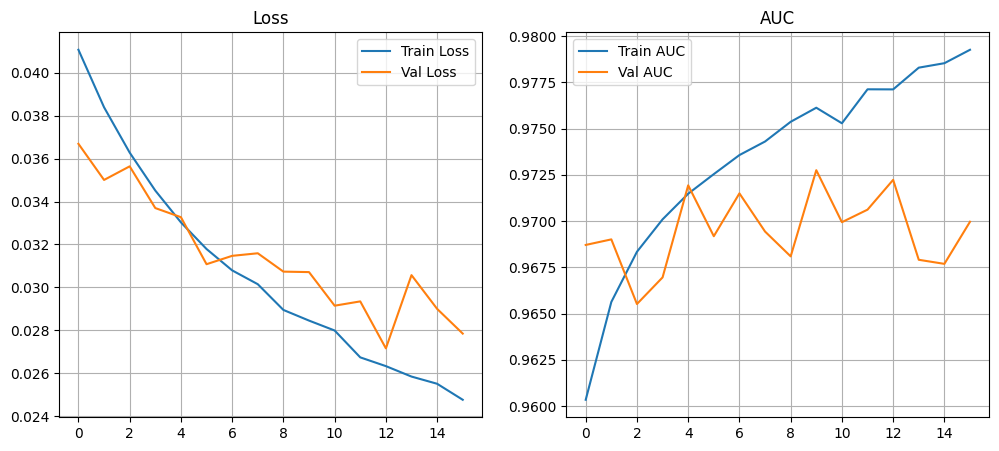

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend(); plt.grid(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label="Train AUC")
plt.plot(history.history['val_auc'], label="Val AUC")
plt.legend(); plt.grid(); plt.title("AUC")

plt.show()

In [18]:
y_pred = (model.predict(X_val) > 0.5).astype(int)

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


In [19]:
from sklearn.metrics import classification_report

y_val_pred = (model.predict(X_val) > 0.5).astype(int)
print(classification_report(y_val, y_val_pred))

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    147118
           1       0.83      0.73      0.78      3184

    accuracy                           0.99    150302
   macro avg       0.91      0.86      0.89    150302
weighted avg       0.99      0.99      0.99    150302



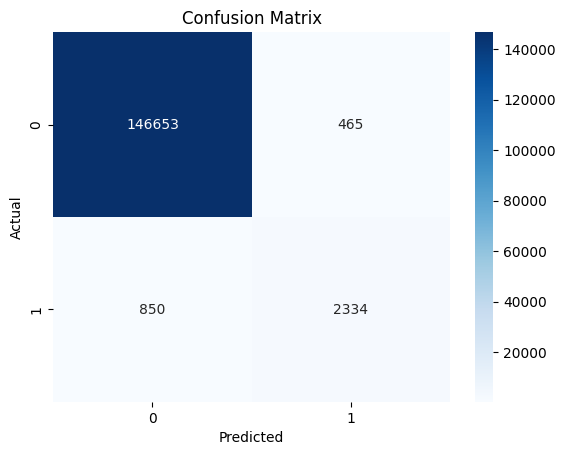

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Validation AUC: 0.9854


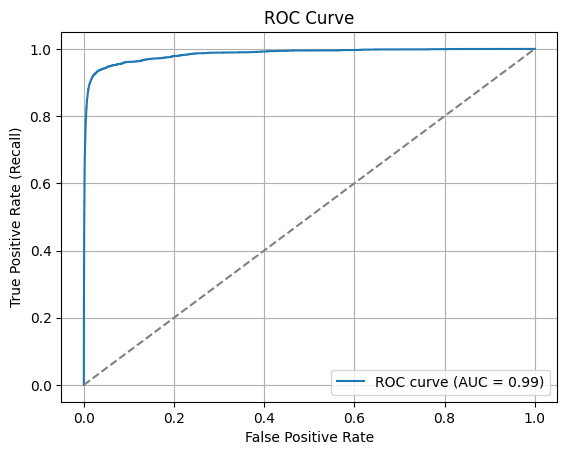

Best threshold: 0.020

Classification report at best threshold:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    147118
           1       0.41      0.93      0.57      3184

    accuracy                           0.97    150302
   macro avg       0.70      0.95      0.78    150302
weighted avg       0.99      0.97      0.98    150302



In [21]:
from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predicted probabilities for validation set
y_val_prob = model.predict(X_val)  # values between 0 and 1

# 2. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)
print(f"Validation AUC: {roc_auc:.4f}")

# 3. Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 4. Find the best threshold
# Method: maximize (Recall - False Positive Rate) → Youden's J statistic
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.3f}")

# 5. Evaluate metrics at this threshold
y_val_pred_best = (y_val_prob >= best_threshold).astype(int)
print("\nClassification report at best threshold:")
print(classification_report(y_val, y_val_pred_best))